## Exercise 1

In [14]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
#import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("code"))

#sns.set_theme(context='notebook',style='white',font_scale=1.5,
            #  rc = {'axes.spines.top':False,'axes.spines.right':False})

In [15]:
# Simulation setup 
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1


spike_positions = [np.interp(s, t, x) for s in spikes]
for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:36<00:00,  1.04it/s]


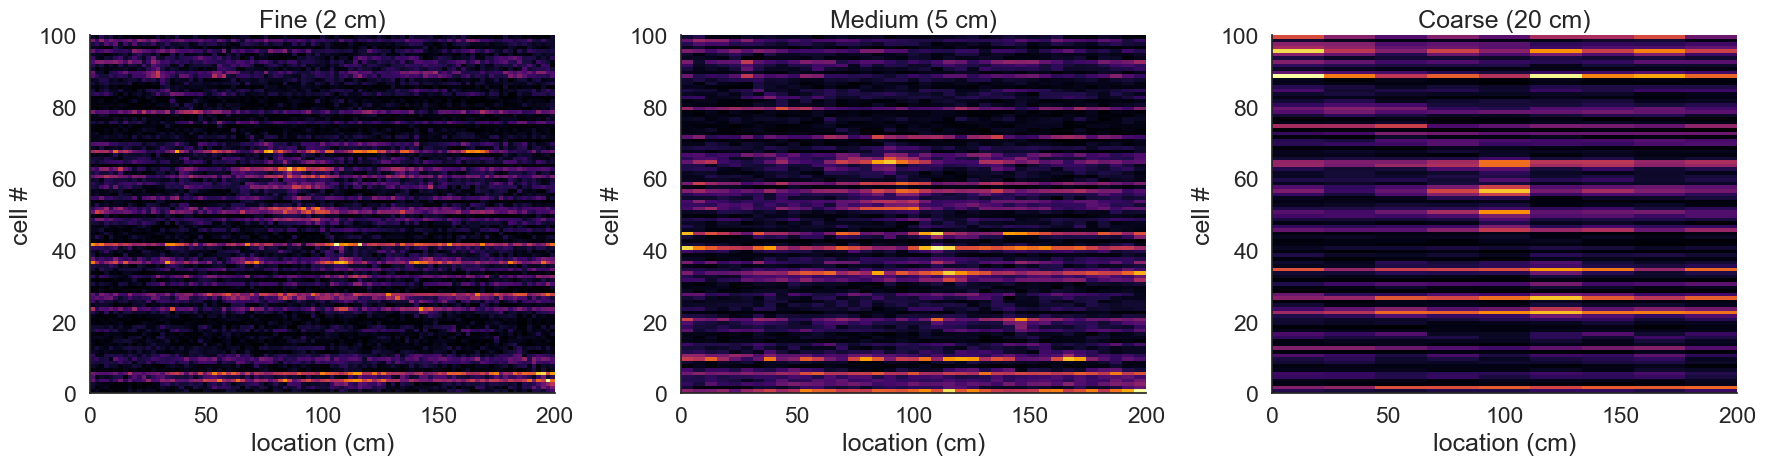

In [16]:
# Exercise A: compare coarse vs fine space_bins
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, bin_size, label in zip(axes, [2., 5., 20.], ['Fine (2 cm)', 'Medium (5 cm)', 'Coarse (20 cm)']):
    space_bins = np.arange(0., 200., bin_size)
    spikes_hist = np.vstack([np.histogram(s, space_bins)[0] for s in spike_positions]).astype(np.float64)
    occupancy = np.histogram(x, space_bins)[0] / fps
    firing_rate_maps = spikes_hist / occupancy
    ix = np.argsort(firing_rate_maps.argmax(axis=1))
    ax.imshow(firing_rate_maps[ix, :], cmap='inferno', aspect='auto', extent=[0, 200, 0, n_cells])
    ax.set_title(label)
    ax.set_xlabel('location (cm)')
    ax.set_ylabel('cell #')

plt.tight_layout()

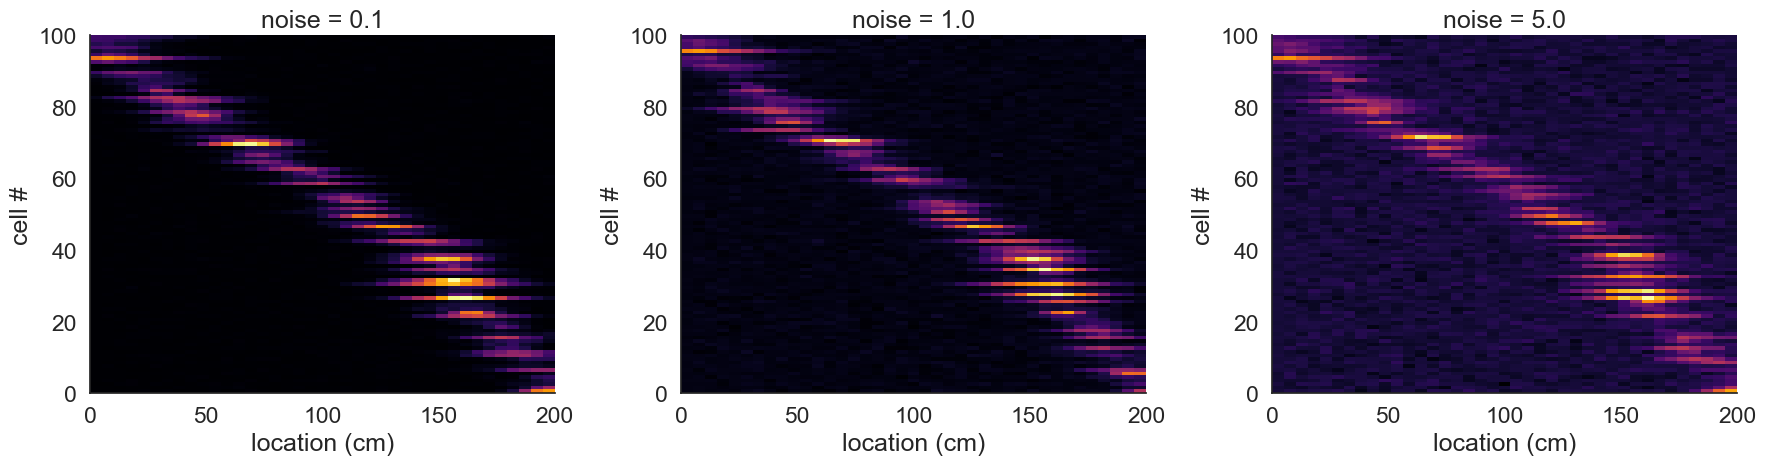

In [17]:
# Exercise B: simulate spikes with different noise_firing_rate values and compare firing rate maps
space_bins = np.arange(0., 200., 5.)
occupancy = np.histogram(x, space_bins)[0] / fps

noise_levels = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, noise in zip(axes, noise_levels):
    spikes_noisy = []
    for i in range(n_cells):
        inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + noise
        spikes_loc = np.random.poisson(inst_rate / sampling_rate)
        sp = np.argwhere(spikes_loc)
        spikes_noisy.append(t_sampling[sp])

    spike_pos_noisy = [np.interp(s, t, x) for s in spikes_noisy]
    spikes_hist = np.vstack([np.histogram(s, space_bins)[0] for s in spike_pos_noisy]).astype(np.float64)
    firing_rate_maps_noisy = spikes_hist / occupancy
    ix = np.argsort(firing_rate_maps_noisy.argmax(axis=1))
    ax.imshow(firing_rate_maps_noisy[ix, :], cmap='inferno', aspect='auto', extent=[0, 200, 0, n_cells])
    ax.set_title(f'noise = {noise}')
    ax.set_xlabel('location (cm)')
    ax.set_ylabel('cell #')

plt.tight_layout()

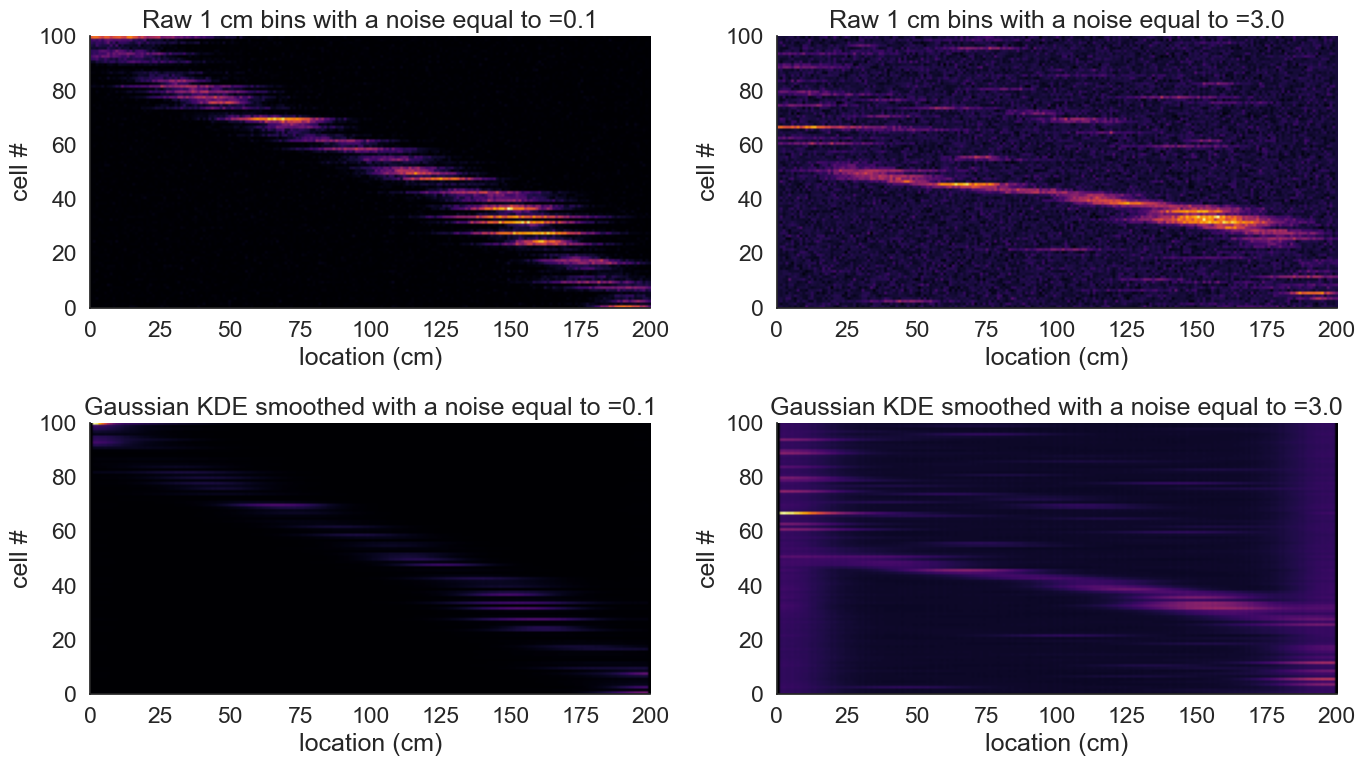

In [18]:
# Exercise C: use scipy.stats.gaussian_kde with 1 cm bins, compare low vs high noise
space_bins_fine = np.arange(0., 200., 1.)
bin_centers = (space_bins_fine[:-1] + space_bins_fine[1:]) / 2
occupancy_fine = np.histogram(x, space_bins_fine)[0] / fps

noise_levels_c = [0.1, 3.0]
cell_example = 10  # pick one representative cell to show

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, noise in enumerate(noise_levels_c):
    spikes_noisy = []
    for i in range(n_cells):
        inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + noise
        spikes_loc = np.random.poisson(inst_rate / sampling_rate)
        sp = np.argwhere(spikes_loc)
        spikes_noisy.append(t_sampling[sp])

    spike_pos_noisy = [np.interp(s, t, x) for s in spikes_noisy]

    # Raw histogram firing rate map (1 cm bins)
    spikes_hist = np.vstack([np.histogram(s, space_bins_fine)[0] for s in spike_pos_noisy]).astype(np.float64)
    firing_rate_maps_fine = spikes_hist / (occupancy_fine + 1e-10)

    # Gaussian KDE smoothed firing rate map
    smoothed_maps = np.zeros_like(firing_rate_maps_fine)
    for i in range(n_cells):
        sp_pos = spike_pos_noisy[i].ravel()
        if len(sp_pos) > 1:
            kde = scipy.stats.gaussian_kde(sp_pos)
            smoothed_maps[i, :] = kde(bin_centers) * len(sp_pos) / (occupancy_fine + 1e-10)

    ix = np.argsort(smoothed_maps.argmax(axis=1))

    axes[0, col].imshow(firing_rate_maps_fine[ix, :], cmap='inferno', aspect='auto', extent=[0, 200, 0, n_cells])
    axes[0, col].set_title(f'Raw 1 cm bins with a noise equal to ={noise}')
    axes[0, col].set_xlabel('location (cm)')
    axes[0, col].set_ylabel('cell #')
    axes[1, col].imshow(smoothed_maps[ix, :], cmap='inferno', aspect='auto', extent=[0, 200, 0, n_cells])
    axes[1, col].set_title(f'Gaussian KDE smoothed with a noise equal to ={noise}')
    axes[1, col].set_xlabel('location (cm)')
    axes[1, col].set_ylabel('cell #')

plt.tight_layout()

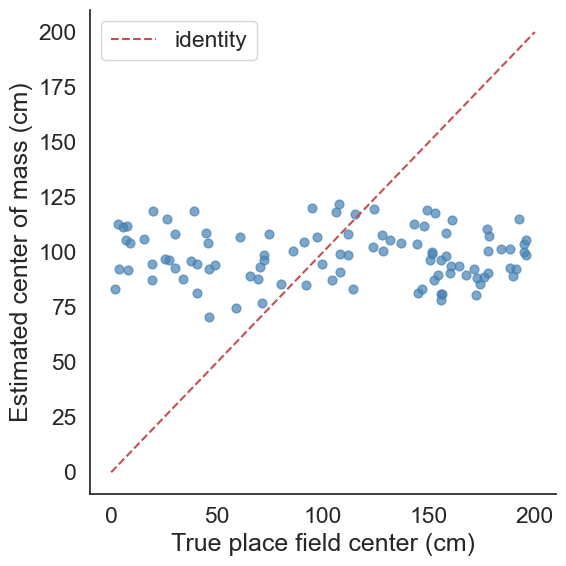

In [19]:
# Exercise D: compute center of mass c_pf = (1/N_spikes) * sum(L_i) for each cell
# and compare with pf_centers (true place field centers from the simulation)
center_of_mass = np.array([
    np.mean(spike_positions[i]) if len(spike_positions[i]) > 0 else np.nan
    for i in range(n_cells)
])

plt.figure(figsize=(6, 6))
plt.scatter(pf_centers, center_of_mass, alpha=0.7, color='steelblue', s=40)
plt.plot([0, 200], [0, 200], 'r--', label='identity')
plt.xlabel('True place field center (cm)')
plt.ylabel('Estimated center of mass (cm)')
plt.legend()
plt.tight_layout()

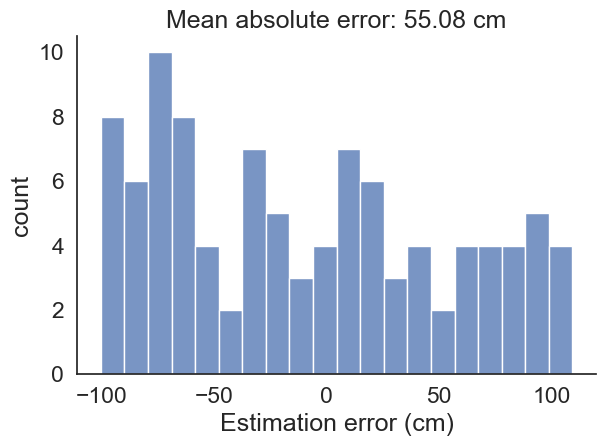

In [20]:
# Exercise D: show estimation error distribution
errors = center_of_mass - pf_centers
sns.histplot(errors, bins=20)
plt.xlabel('Estimation error (cm)')
plt.ylabel('count')
plt.title(f'Mean absolute error: {np.nanmean(np.abs(errors)):.2f} cm')
plt.tight_layout()

## Exercise 2

In [23]:
space_bins = np.arange(0., 200., 5.)
spikes_hist = np.vstack([np.histogram(s, space_bins)[0] for s in spike_positions]).astype(np.float64)
occupancy = np.histogram(x, space_bins)[0] / fps
firing_rate_maps = spikes_hist / occupancy

In [24]:
# Exercise A
def spatial_information(firing_rate_map, occupancy):
    """Return spatial information in bits/s and bits/spike."""
    eps = 1e-15
    p_occ = occupancy / occupancy.sum()          # normalise occupancy to probability
    lam_mean = (firing_rate_map * p_occ).sum()   # average firing rate
    I = np.sum(firing_rate_map * np.log2((firing_rate_map + eps) / (lam_mean + eps)) * p_occ)
    I_s = I / (lam_mean + eps)                   # bits/spike
    return I, I_s

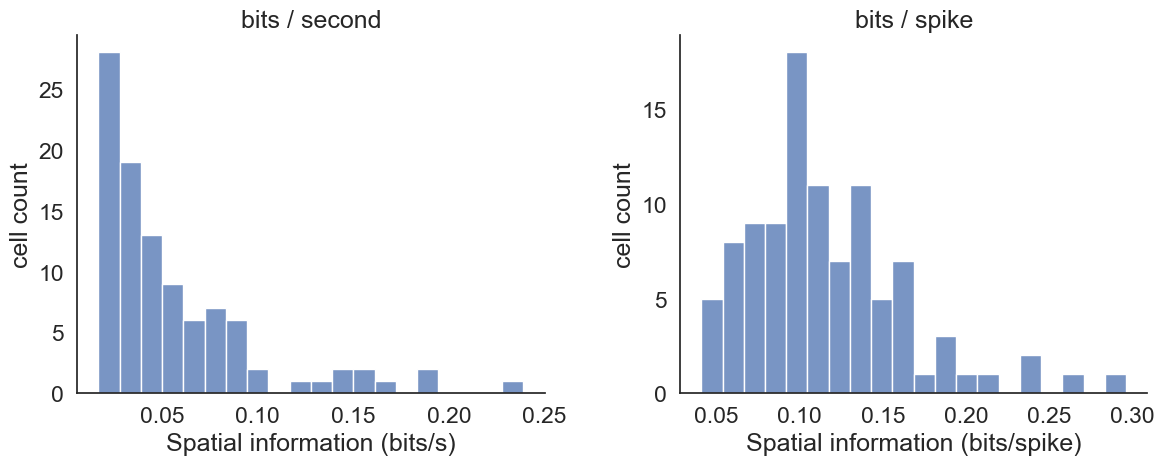

In [25]:
# compute spatial information for all 100 simulated cells
info_bps   = np.zeros(n_cells)   # bits/s
info_bpspk = np.zeros(n_cells)   # bits/spike

for i in range(n_cells):
    info_bps[i], info_bpspk[i] = spatial_information(firing_rate_maps[i], occupancy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(info_bps, bins=20, ax=axes[0])
axes[0].set_xlabel('Spatial information (bits/s)')
axes[0].set_ylabel('cell count')
axes[0].set_title('bits / second')

sns.histplot(info_bpspk, bins=20, ax=axes[1])
axes[1].set_xlabel('Spatial information (bits/spike)')
axes[1].set_ylabel('cell count')
axes[1].set_title('bits / spike')

plt.tight_layout()

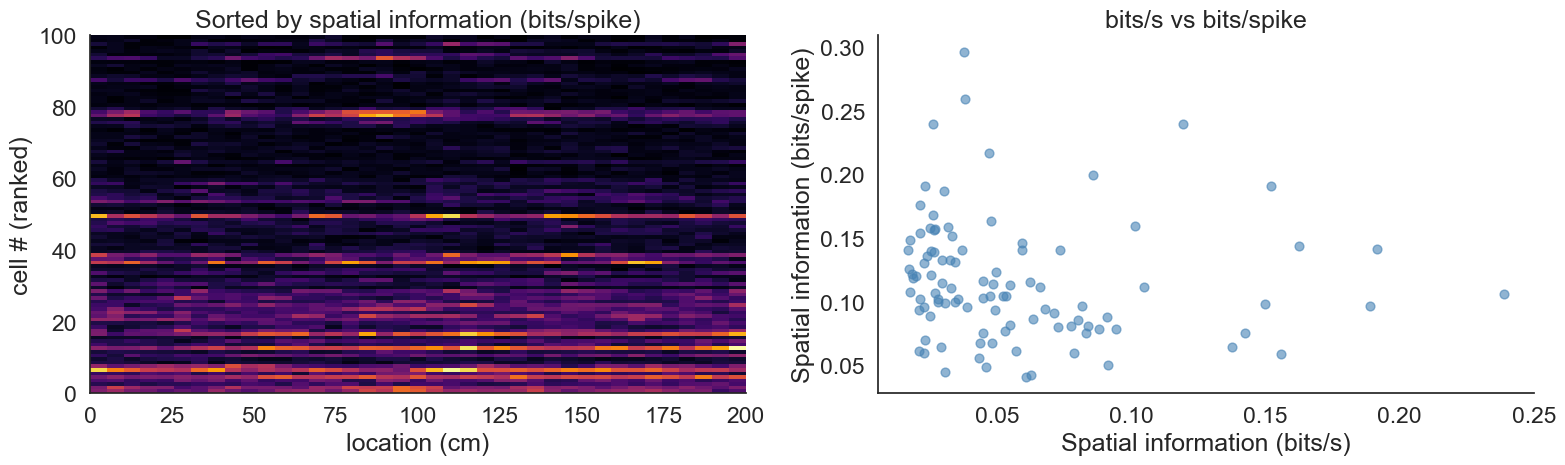

In [26]:
#visualise firing rate maps ranked by spatial information (bits/spike)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ix_info = np.argsort(info_bpspk)[::-1]   # highest information first

axes[0].imshow(firing_rate_maps[ix_info, :], cmap='inferno', aspect='auto', extent=[0, 200, 0, n_cells])
axes[0].set_title('Sorted by spatial information (bits/spike)')
axes[0].set_xlabel('location (cm)')
axes[0].set_ylabel('cell # (ranked)')

axes[1].scatter(info_bps, info_bpspk, alpha=0.6, color='steelblue', s=40)
axes[1].set_xlabel('Spatial information (bits/s)')
axes[1].set_ylabel('Spatial information (bits/spike)')
axes[1].set_title('bits/s vs bits/spike')

plt.tight_layout()

In [27]:
# Exercise B:  simulate one population and return mean spatial information
def simulate_and_compute_info(pf_rate_val, pf_size_val, noise_val, n_cells=30, n_runs=10, seed=0):
    """Simulate place cells with fixed parameters, return mean I (bits/s) and I_s (bits/spike)."""
    rng = np.random.default_rng(seed)

    pf_centers_sim = rng.random(n_cells) * track_length
    pf_size_sim    = np.full(n_cells, pf_size_val)
    pf_rate_sim    = np.full(n_cells, pf_rate_val)

    tfr = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        tfr[i] = pf_rate_sim[i] * np.exp(-((bins - pf_centers_sim[i])**2) / (2 * pf_size_sim[i]**2))

    # trajectory
    rs_a = rng.chisquare(10, size=n_runs)
    rs_b = rng.chisquare(10, size=n_runs)
    st_a = rng.chisquare(15, size=n_runs)
    st_b = rng.chisquare(15, size=n_runs)
    xsim = np.array([])
    for i in range(n_runs):
        xsim = np.concatenate([
            xsim,
            np.ones(int(st_a[i] * fps)) * 0.,
            np.linspace(0., len(bins) - 1., int(len(bins) * fps / rs_a[i])),
            np.ones(int(st_b[i] * fps)) * (len(bins) - 1.),
            np.linspace(len(bins) - 1., 0., int(len(bins) * fps / rs_b[i]))
        ])
    tsim = np.arange(len(xsim)) / fps

    t_s = np.arange(0, tsim[-1], 1. / sampling_rate)
    x_s = np.floor(np.interp(t_s, tsim, xsim))

    spk_pos = []
    for i in range(n_cells):
        inst = tfr[i, x_s.astype(np.int32)] + noise_val
        sp = np.argwhere(rng.poisson(inst / sampling_rate))
        spk_pos.append(np.interp(t_s[sp], tsim, xsim))

    occ = np.histogram(xsim, space_bins)[0] / fps
    sh  = np.vstack([np.histogram(s, space_bins)[0] for s in spk_pos]).astype(np.float64)
    frm = sh / (occ + 1e-10)

    I_all, Is_all = zip(*[spatial_information(frm[i], occ) for i in range(n_cells)])
    return np.mean(I_all), np.mean(Is_all)

## Exercise 3

In [28]:
# Exercise 3: load real data
import pickle

data_path = r'C:\Users\vitto\OneDrive\Desktop\MyProject\data\linear_track_data.pickle'

with open(data_path, 'rb') as f:
    data = pickle.load(f)

x      = data['x']    # position of the animal
t      = data['t']  # timestamps (seconds)
spikes = data['spikes']  # list of spike timestamp arrays, one per neuron

n_cells = len(spikes)
print(f'{n_cells} cells, {len(t)} position samples, duration: {t[-1]:.1f} s')

72 cells, 37837 position samples, duration: 1261.8 s


C:\Users\vitto\AppData\Local\Temp\ipykernel_25804\1116500959.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


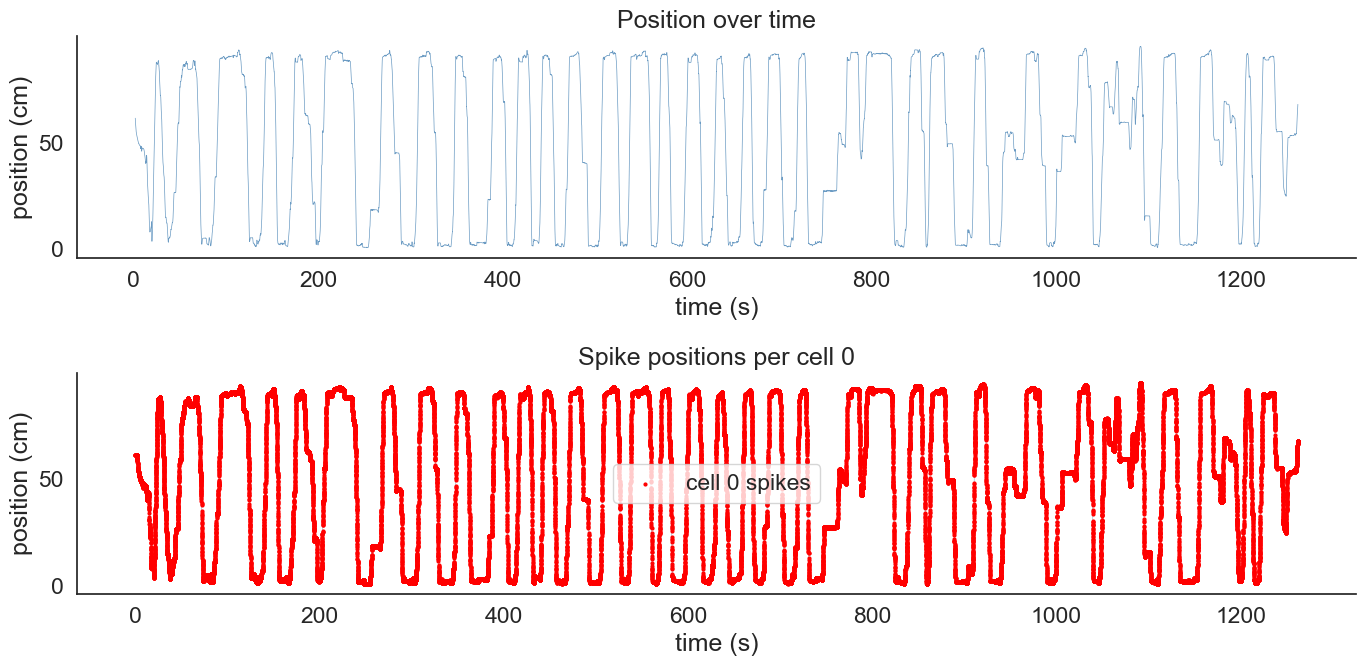

In [33]:
# Exercise 3A: visualize position over time and spike locations of one cell
cell_id = 0
spike_pos = np.interp(spikes[cell_id], t, x)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(t, x, color='steelblue', lw=0.5, alpha=0.8)
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('position (cm)')
axes[0].set_title('Position over time')

axes[1].plot(t, x, color='steelblue', lw=0.5, alpha=0.5)
axes[1].scatter(spikes[cell_id], spike_pos, color='red', s=4, zorder=3, label=f'cell {cell_id} spikes')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('position (cm)')
axes[1].set_title(f'Spike positions per cell {cell_id}')
axes[1].legend()

plt.tight_layout()

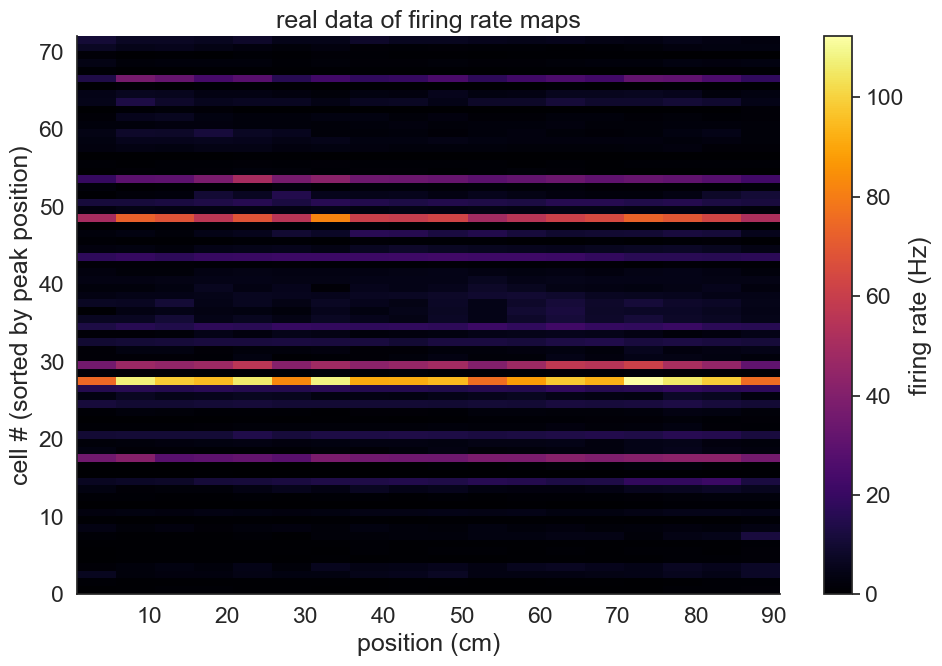

In [34]:
# Exercise 3B: firing rate maps for all cells, sorted by peak position
space_bins = np.arange(x.min(), x.max(), 5.)
occupancy  = np.histogram(x, space_bins)[0] / (1. / np.mean(np.diff(t)))  # seconds per bin

spike_positions_real = [np.interp(spikes[i], t, x) for i in range(n_cells)]
spikes_hist = np.vstack([np.histogram(s, space_bins)[0]
                         for s in spike_positions_real]).astype(np.float64)
firing_rate_maps = spikes_hist / (occupancy + 1e-10)

ix = np.argsort(firing_rate_maps.argmax(axis=1))

plt.figure(figsize=(10, 7))
plt.imshow(firing_rate_maps[ix, :], cmap='inferno', aspect='auto',
           extent=[space_bins[0], space_bins[-1], 0, n_cells])
plt.xlabel('position (cm)')
plt.ylabel('cell # (sorted by peak position)')
plt.title('real data of firing rate maps')
plt.colorbar(label='firing rate (Hz)')
plt.tight_layout()

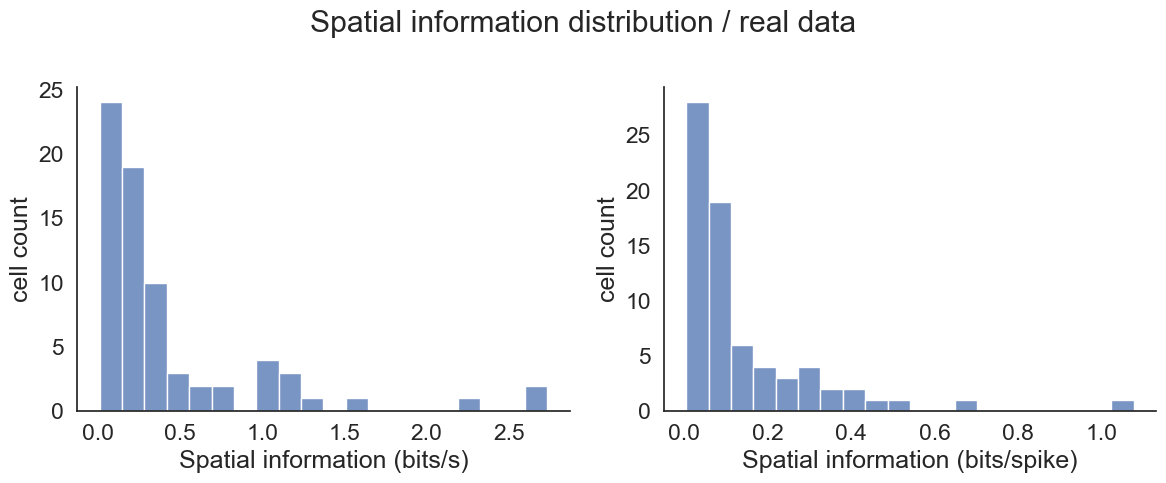

In [35]:
# Exercise 3C: spatial information for each cell
info_bps   = np.zeros(n_cells)
info_bpspk = np.zeros(n_cells)

for i in range(n_cells):
    info_bps[i], info_bpspk[i] = spatial_information(firing_rate_maps[i], occupancy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(info_bps,   bins=20, ax=axes[0])
axes[0].set_xlabel('Spatial information (bits/s)')
axes[0].set_ylabel('cell count')

sns.histplot(info_bpspk, bins=20, ax=axes[1])
axes[1].set_xlabel('Spatial information (bits/spike)')
axes[1].set_ylabel('cell count')

plt.suptitle('Spatial information distribution / real data')
plt.tight_layout()

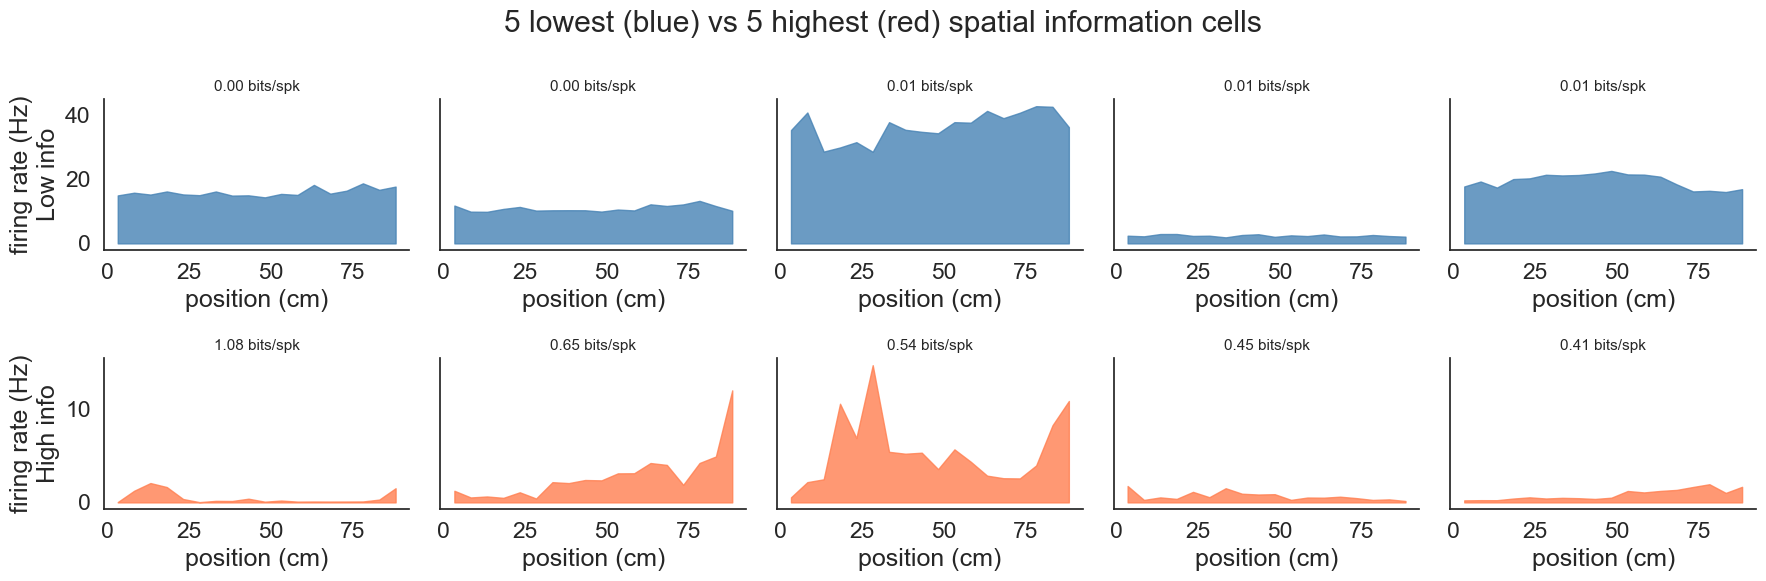

In [32]:
# plot 5 lowest and 5 highest spatial information cells (bits/spike)
bin_centers = (space_bins[:-1] + space_bins[1:]) / 2

sorted_idx  = np.argsort(info_bpspk)
low5  = sorted_idx[:5]
high5 = sorted_idx[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey='row')

for col, (lo, hi) in enumerate(zip(low5, high5)):
    axes[0, col].fill_between(bin_centers, firing_rate_maps[lo],  color='steelblue', alpha=0.8)
    axes[0, col].set_title(f'{info_bpspk[lo]:.2f} bits/spk', fontsize=11)
    axes[0, col].set_xlabel('position (cm)')
    if col == 0:
        axes[0, col].set_ylabel('firing rate (Hz)\nLow info')

    axes[1, col].fill_between(bin_centers, firing_rate_maps[hi], color='coral', alpha=0.8)
    axes[1, col].set_title(f'{info_bpspk[hi]:.2f} bits/spk', fontsize=11)
    axes[1, col].set_xlabel('position (cm)')
    if col == 0:
        axes[1, col].set_ylabel('firing rate (Hz)\nHigh info')

plt.suptitle('5 lowest (blue) vs 5 highest (red) spatial information cells')
plt.tight_layout()